In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

In [2]:
data=pd.read_excel("heart_disease.xlsx")
print(data.head())

   HP        MPG  VOL          SP         WT
0  49  53.700681   89  104.185353  28.762059
1  55  50.013401   92  105.461264  30.466833
2  55  50.013401   92  105.461264  30.193597
3  70  45.696322   92  113.461264  30.632114
4  53  50.504232   92  104.461264  29.889149


In [3]:
print("Check dataset information")
print(data.info())

Check dataset information
<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HP      81 non-null     int64  
 1   MPG     81 non-null     float64
 2   VOL     81 non-null     int64  
 3   SP      81 non-null     float64
 4   WT      81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB
None


In [4]:
print("check missing values")
print(data.isnull().sum())

check missing values
HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64


In [5]:
print("Statistical summary")
print(data.describe())

Statistical summary
               HP        MPG         VOL          SP         WT
count   81.000000  81.000000   81.000000   81.000000  81.000000
mean   117.469136  34.422076   98.765432  121.540272  32.412577
std     57.113502   9.131445   22.301497   14.181432   7.492813
min     49.000000  12.101263   50.000000   99.564907  15.712859
25%     84.000000  27.856252   89.000000  113.829145  29.591768
50%    100.000000  35.152727  101.000000  118.208698  32.734518
75%    140.000000  39.531633  113.000000  126.404312  37.392524
max    322.000000  53.700681  160.000000  169.598513  52.997752


# Visualization


In [6]:
# Visualization

#Histogram 
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
data[numeric_cols].hist(figsize=(20,10))
plt.show()


KeyError: "None of [Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak'], dtype='str')] are in the [columns]"

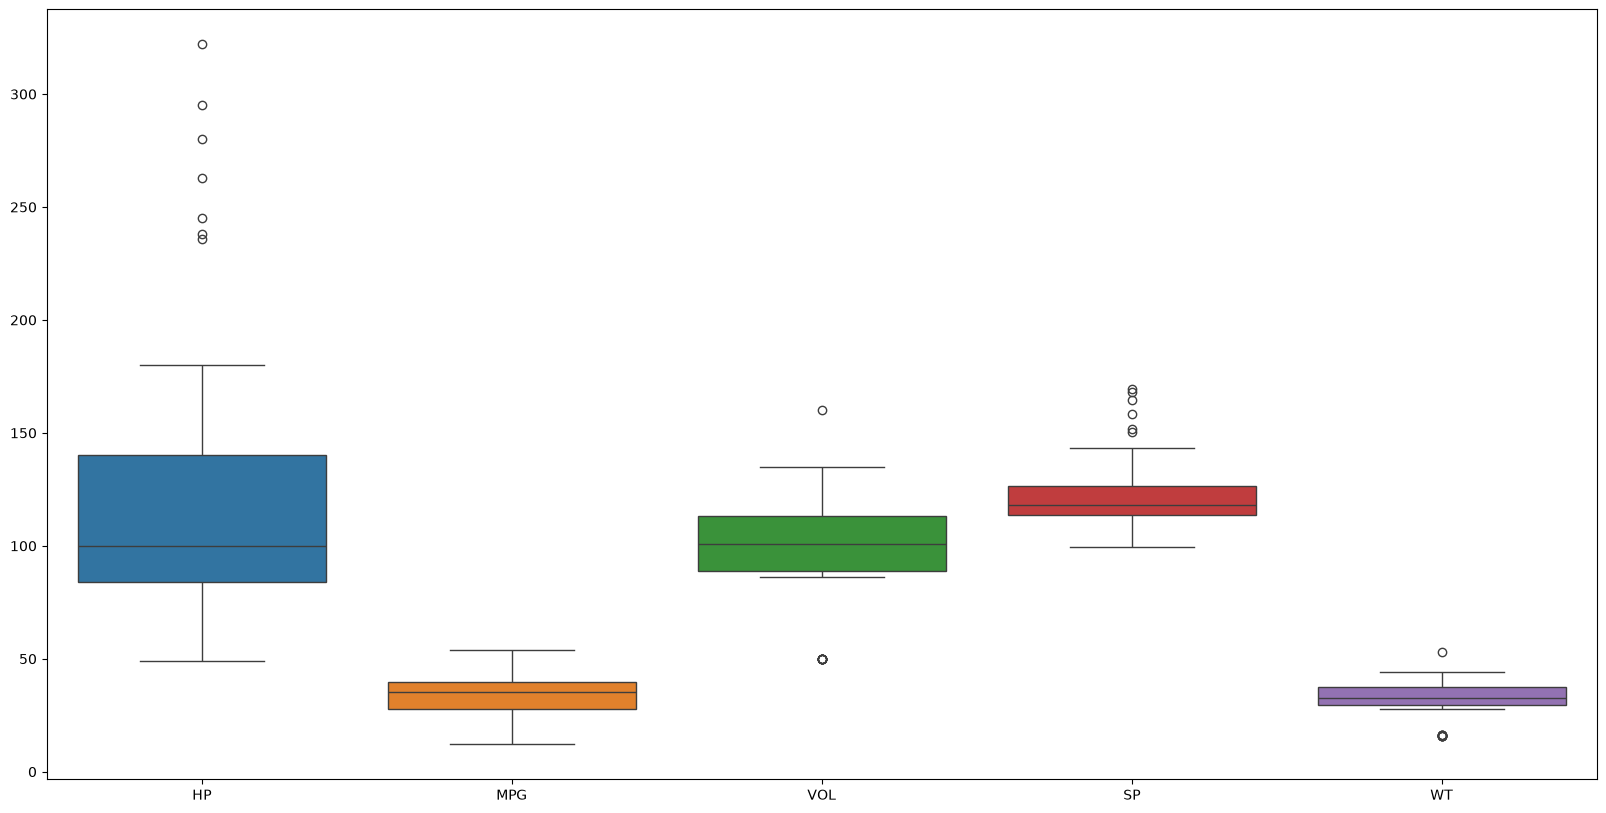

In [7]:
#Boxplot
plt.figure(figsize=(20,10))
sns.boxplot(data=data)
plt.show()

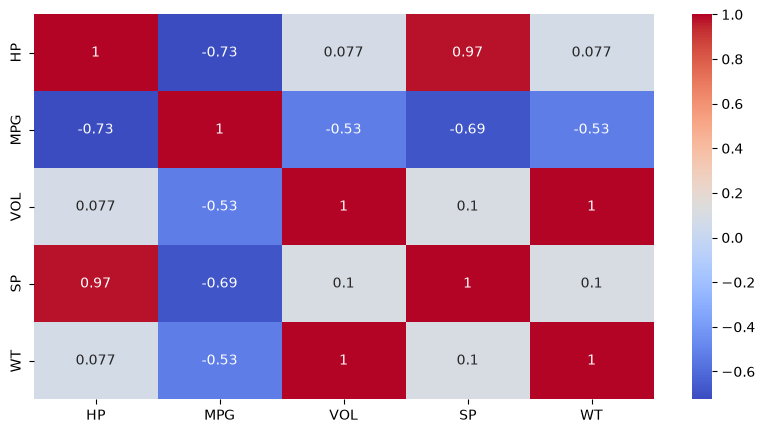

In [8]:
# Correlation matrices.
plt.figure(figsize=(10,5))
sns.heatmap(data.corr(),annot=True, cmap="coolwarm")
plt.show()

# Feature Engineering

In [9]:
data.fillna(data.mean(),inplace=True)

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [10]:
data=pd.get_dummies(data,drop_first=True)
print(data)

     HP        MPG  VOL          SP         WT
0    49  53.700681   89  104.185353  28.762059
1    55  50.013401   92  105.461264  30.466833
2    55  50.013401   92  105.461264  30.193597
3    70  45.696322   92  113.461264  30.632114
4    53  50.504232   92  104.461264  29.889149
..  ...        ...  ...         ...        ...
76  322  36.900000   50  169.598513  16.132947
77  238  19.197888  115  150.576579  37.923113
78  263  34.000000   50  151.598513  15.769625
79  295  19.833733  119  167.944460  39.423099
80  236  12.101263  107  139.840817  34.948615

[81 rows x 5 columns]


# Decision Tr ee Classification

In [11]:
x=data.drop("VOL",axis=1)
y=data["VOL"]
print(x,"\n",y)

     HP        MPG          SP         WT
0    49  53.700681  104.185353  28.762059
1    55  50.013401  105.461264  30.466833
2    55  50.013401  105.461264  30.193597
3    70  45.696322  113.461264  30.632114
4    53  50.504232  104.461264  29.889149
..  ...        ...         ...        ...
76  322  36.900000  169.598513  16.132947
77  238  19.197888  150.576579  37.923113
78  263  34.000000  151.598513  15.769625
79  295  19.833733  167.944460  39.423099
80  236  12.101263  139.840817  34.948615

[81 rows x 4 columns] 
 0      89
1      92
2      92
3      92
4      92
     ... 
76     50
77    115
78     50
79    119
80    107
Name: VOL, Length: 81, dtype: int64


In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train,x_test,y_train,y_test)

     HP        MPG          SP         WT
61  120  24.609132  117.668550  37.860411
55  130  27.856252  126.404312  40.589068
40   95  35.152727  116.392639  37.392524
9    80  42.299078  115.645204  30.920154
64  150  23.605158  128.128401  40.159482
..  ...        ...         ...        ...
20   92  38.411003  119.105055  32.324650
60  145  27.354265  130.208698  36.888153
71  162  23.203569  133.415985  44.013139
14   66  45.734893  108.185353  29.347279
51  115  29.629936  118.288996  33.436711

[64 rows x 4 columns]      HP        MPG          SP         WT
30   84  39.431235  113.484609  37.042350
0    49  53.700681  104.185353  28.762059
22   95  38.310606  120.288996  32.675828
31   84  39.431235  112.288996  33.234361
18   78  42.789909  114.369293  29.929394
28   52  43.469434   99.564907  34.483207
10   73  44.652834  111.185353  29.363341
70  280  19.678507  164.598513  15.823060
4    53  50.504232  104.461264  29.889149
12   92  39.354094  122.105055  32.813592
49  115  29

In [13]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [14]:
y_pred= dt.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.4117647058823529


              precision    recall  f1-score   support

          50       1.00      1.00      1.00         1
          89       1.00      1.00      1.00         2
          91       0.00      0.00      0.00         1
          92       0.50      1.00      0.67         1
          97       0.00      0.00      0.00         0
          98       0.00      0.00      0.00         1
          99       0.00      0.00      0.00         2
         101       0.50      0.67      0.57         3
         104       0.00      0.00      0.00         1
         107       0.00      0.00      0.00         0
         111       0.00      0.00      0.00         0
         113       1.00      1.00      1.00         1
         114       0.00      0.00      0.00         1
         123       0.00      0.00      0.00         1
         127       0.00      0.00      0.00         1
         129       0.00      0.00      0.00         0
         160       0.00      0.00      0.00         1

    accuracy              

# Hyperparameter Tuning 

In [15]:
param_grid ={
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]}
grid =GridSearchCV(DecisionTreeClassifier(),param_grid,cv=5)
grid.fit(x_train,y_train)

best_model =grid.best_estimator_
print("Best Parametres:",grid.best_params_)

Best Parametres: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}


# Model Evaluation & Tree Visualization

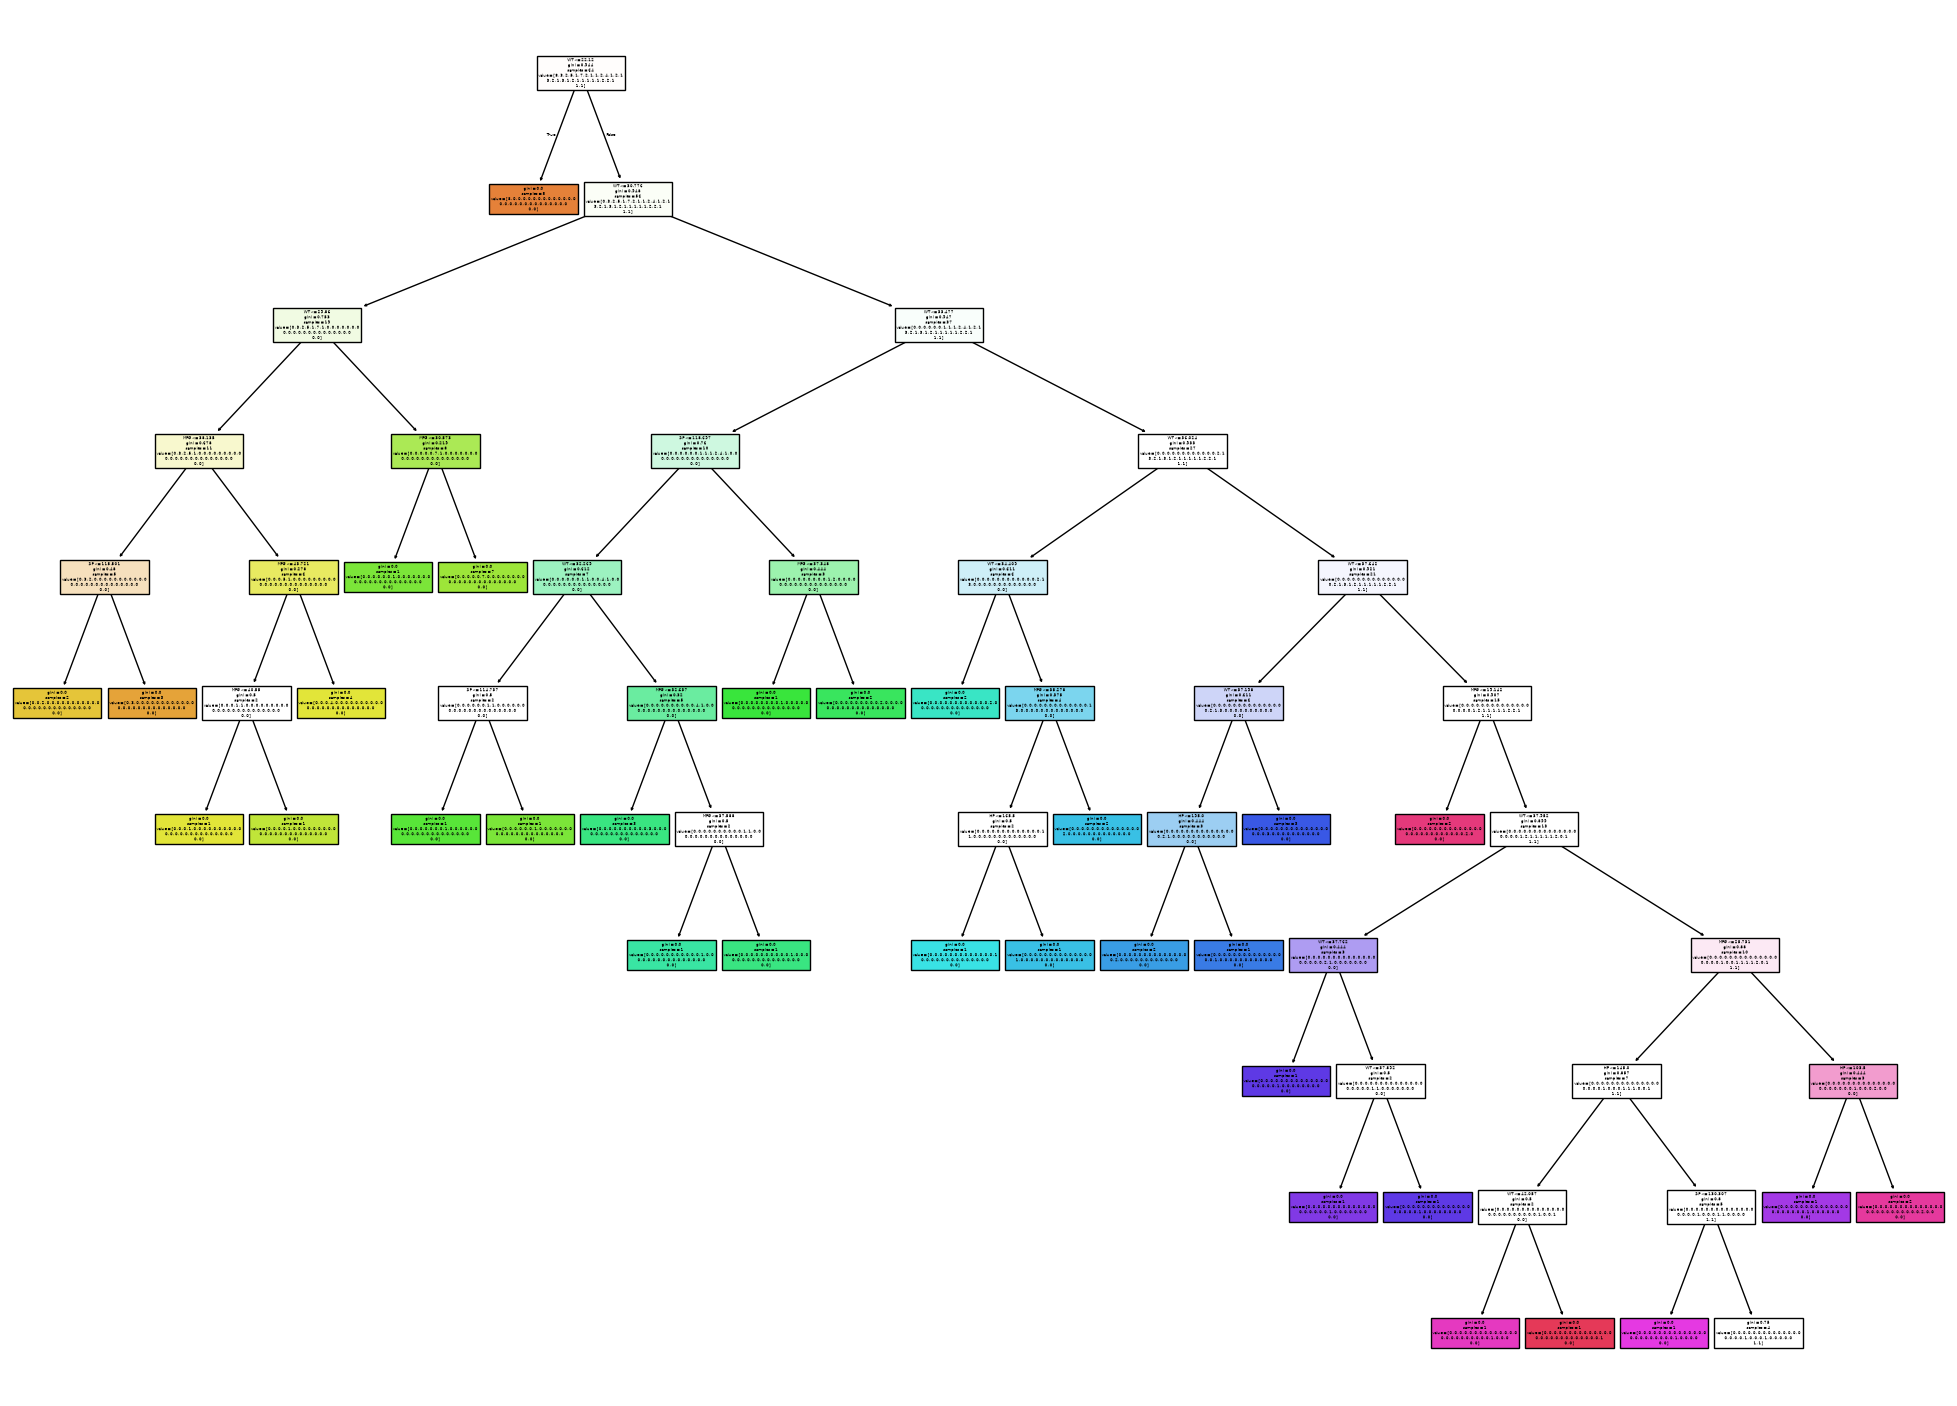

In [16]:
plt.figure(figsize=(25,18))
plot_tree(best_model,filled=True,feature_names=x.columns)
plt.show()